In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import sys
import os
sys.path.append(os.path.abspath("../Code"))
import vectorize
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../Data/raw/tcga_simple_train.csv')

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=23)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=33)

m_train,v = vectorize.vectorizacionBinaria(X_train)
m_test = v.transform(X_test)
m_val = v.transform(X_val)

le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_val_num = le.transform(y_val)
y_test_num = le.transform(y_test)

MAX_LEN = 200


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM
model = Sequential([
    
    Embedding(input_dim=len(v.get_feature_names_out()) + 1, output_dim=16, input_length=MAX_LEN),


    LSTM(units=8, 
              activation='tanh', 
              dropout=0.6,
              recurrent_dropout=0),

    Dense(4,activation='softmax')
])

model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c:\Users\tcspo\Desktop\Codigo_Clases\PLN1\practica\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_map = v.vocabulary_
index_mapping = {word: (idx + 1) for word, idx in vocab_map.items()} # 0 es padding

def texto_a_secuencia(serie_texto, mapping, max_len):
    sequencias = []
    for texto in serie_texto:

        seq = [mapping[w] for w in texto.split() if w in mapping]
        sequencias.append(seq)

    return pad_sequences(sequencias, maxlen=max_len)
X_train_rnn = texto_a_secuencia(X_train, index_mapping, MAX_LEN)
X_val_rnn = texto_a_secuencia(X_val, index_mapping, MAX_LEN)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn, y_train_num,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_rnn, y_val_num)
)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.3361 - loss: 1.3683 - val_accuracy: 0.3208 - val_loss: 1.3492
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3458 - loss: 1.3192 - val_accuracy: 0.3257 - val_loss: 1.3094
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3976 - loss: 1.2733 - val_accuracy: 0.3947 - val_loss: 1.2773
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4397 - loss: 1.2275 - val_accuracy: 0.4249 - val_loss: 1.2562
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4776 - loss: 1.1833 - val_accuracy: 0.4165 - val_loss: 1.2482
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4958 - loss: 1.1456 - val_accuracy: 0.4262 - val_loss: 1.2457
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5061 - loss: 1.1262 - val_accuracy: 0.4225 - val_loss: 1.2510
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5276 - loss: 1.0875 - val_accuracy: 0.4177 - v

In [25]:
X_test_rnn = texto_a_secuencia(X_test, index_mapping, MAX_LEN)

predicciones_prob = model.predict(X_test_rnn)
clases_predichas = np.argmax(predicciones_prob, axis=1)

print(classification_report(y_test_num,clases_predichas))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.41      0.46      0.43       247
           1       0.50      0.49      0.49       354
           2       0.48      0.55      0.51       310
           3       0.30      0.14      0.19       121

    accuracy                           0.46      1032
   macro avg       0.42      0.41      0.41      1032
weighted avg       0.45      0.46      0.45      1032



# Ahora con los embbedings contextuales

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 50, 768)
X_test: (1032, 50, 768)
y_train: (4126,)
y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │       213,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,084 (898.77 KB)

 Trainable params: 230,084 (898.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2619 - loss: 1.5785 — val_f1_macro: 0.1389 — val_f1_weighted: 0.1828
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2944 - loss: 1.5486 - val_accuracy: 0.3220 - val_loss: 1.5073 - val_f1_macro: 0.1389 - val_f1_weighted: 0.1828 - learning_rate: 5.0000e-05
Epoch 2/200
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3244 - loss: 1.5110 — val_f1_macro: 0.1640 — val_f1_weighted: 0.2114
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3267 - loss: 1.5055 - val_accuracy: 0.2881 - val_loss: 1.4926 - val_f1_macro: 0.1640 - val_f1_weighted: 0.2114 - learning_rate: 5.0000e-05
Epoch 3/200
114/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3303 - loss: 1.4936 — val_f1_macro: 0.1801 — val_f1_weighted: 0.2310
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3283 - loss: 1.4924 - val_accuracy: 0.2906 - val_loss: 1.4852 - val_f1_macro: 0.1801 - val_f1_weighted: 0.2310 - learning_rate: 5.0000e-05
Epoc

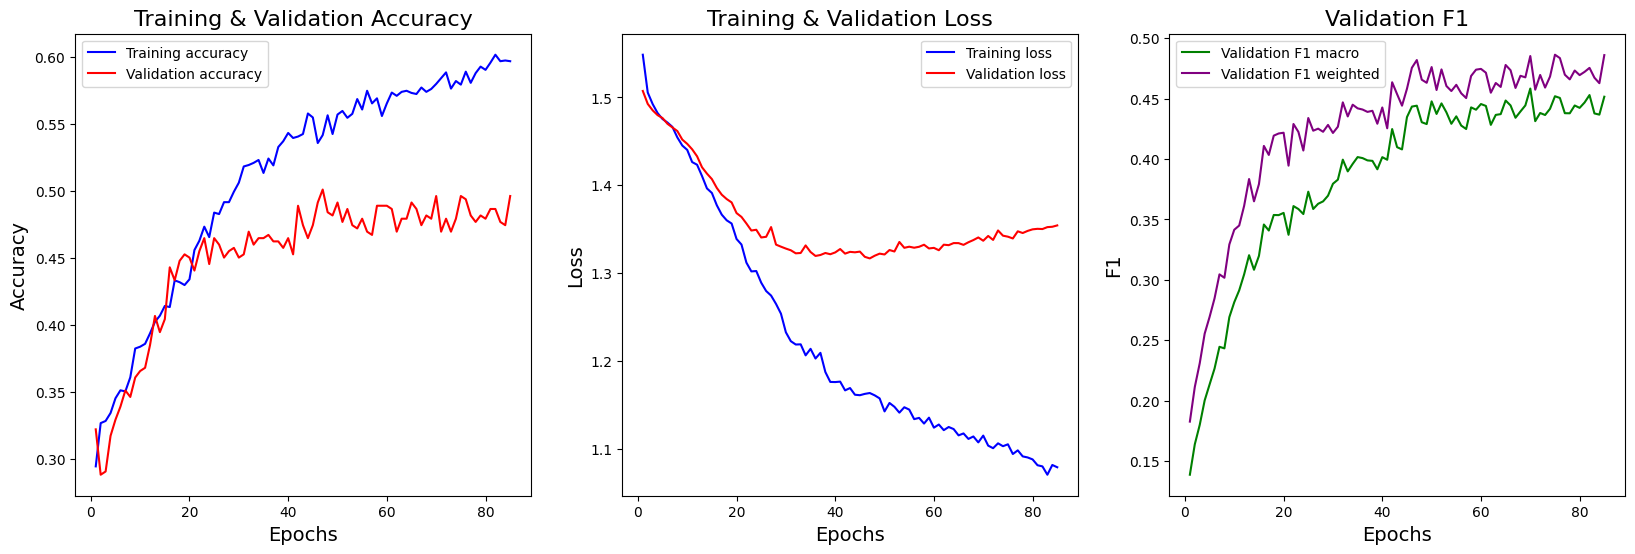

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


# --------------------------------------------------
# cargar embeddings contextuales sin pooling
# cambia estas rutas según quieras BERT o ELMo
# --------------------------------------------------
ruta = "../data/processed/bert"
# BERT sin pooling
X_train = np.load(f"{ruta}/X_train_bert_tokens.npy", mmap_mode='r')
X_test = np.load(f"{ruta}/X_test_bert_tokens.npy", mmap_mode='r')

# ELMo sin pooling
# X_train = np.load(f"{ruta}/X_train_elmo_tokens.npy", mmap_mode='r')
# X_test = np.load(f"{ruta}/X_test_elmo_tokens.npy", mmap_mode='r')

df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

# pasamos etiquetas a enteros
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# --------------------------------------------------
# validación manual para poder calcular F1 por época
# --------------------------------------------------
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)


# --------------------------------------------------
# callback para F1 en validación
# --------------------------------------------------
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.val_f1_macro = []
        self.val_f1_weighted = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_pred_probs = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        f1_macro = f1_score(self.y_val, y_pred, average='macro')
        f1_weighted = f1_score(self.y_val, y_pred, average='weighted')

        self.val_f1_macro.append(f1_macro)
        self.val_f1_weighted.append(f1_weighted)

        logs["val_f1_macro"] = f1_macro
        logs["val_f1_weighted"] = f1_weighted

        print(f" — val_f1_macro: {f1_macro:.4f} — val_f1_weighted: {f1_weighted:.4f}")


# --------------------------------------------------
# modelo LSTM
# la entrada ya tiene forma (num_textos, num_tokens, dim_embedding)
# --------------------------------------------------
num_clases = len(le.classes_)

model = Sequential()

model.add(LSTM(
    64,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# --------------------------------------------------
# callbacks
# --------------------------------------------------
f1_callback = F1Callback(validation_data=(X_val, y_val))

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_f1_macro',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=0.00001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_f1_macro',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)


# --------------------------------------------------
# entrenamiento
# --------------------------------------------------
history = model.fit(
    X_train_sub,
    y_train_sub,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[f1_callback, reduce_lr, early_stop],
    verbose=1
)


# --------------------------------------------------
# evaluación
# --------------------------------------------------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test, verbose=0)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))


# --------------------------------------------------
# gráficas
# --------------------------------------------------
history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

val_f1_macro = f1_callback.val_f1_macro
val_f1_weighted = f1_callback.val_f1_weighted

epochs = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].plot(epochs, accuracy_vals, 'b', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend()

ax[1].plot(epochs, loss_values, 'b', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=14)
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].legend()

ax[2].plot(epochs, val_f1_macro, 'green', label='Validation F1 macro')
ax[2].plot(epochs, val_f1_weighted, 'purple', label='Validation F1 weighted')
ax[2].set_title('Validation F1', fontsize=16)
ax[2].set_xlabel('Epochs', fontsize=14)
ax[2].set_ylabel('F1', fontsize=14)
ax[2].legend()

plt.show()
